In [2]:
import matplotlib.pyplot as plt
import cv2
import os

In [4]:
image_path = os.path.join("..", "images", "leaf.webp")
image = cv2.imread(image_path)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [6]:
def show_image(img,title,cmap=None):
    plt.figure(figsize=(3,3))
    plt.imshow(img,cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

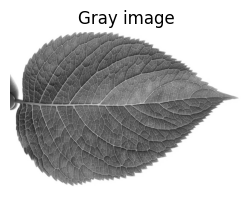

In [8]:
show_image(gray_image,"Gray image",cmap="gray")

In [10]:
import numpy as np
def gaussian_kernel(size, sigma):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / np.sum(kernel)


In [12]:
def convolve2d(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    result = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            result[i, j] = np.sum(padded[i:i+kh, j:j+kw] * kernel)
    return result

In [14]:
kernel1 = gaussian_kernel(size=9, sigma=1)
kernel2 = gaussian_kernel(size=9, sigma=2)

gauss1 = convolve2d(gray_image, kernel1)
gauss2 = convolve2d(gray_image, kernel2)


In [16]:
dog = gauss1 - gauss2

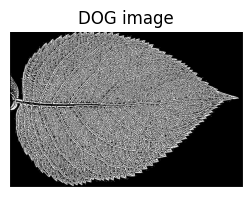

In [18]:
show_image(dog,"DOG image",cmap="gray")